In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import tplquad
from scipy.special import spherical_jn

# Double Folding model

$$ {\underline{\fbox{ $U_D = \int d\vec{r_1}^3 d\vec{r_2}^3 \rho_T(\vec{r_2}) v_d(\rho, E, s) \rho_p(\vec{r_1})$}}}$$

### $ U_D(R) $ Direct Part of $^{16}O + ^{16}O $

$$U_D(R) = \int^\infty _0 \int^\infty _0 \int^\infty _0 \underbrace{k^2 j_0(kR) v_D(k) F(\rho) g(E)}_{I_{V_D}} \:\: \underbrace{ r_1^2 j_0(kr_1) \rho_p(r_1) }_{I_p} \:\: \underbrace{ r_2^2 j_0(kr_2) \rho_t(r_2)}_{I_T} dk dr_1 dr_2$$

### Potenial

$$V_D(s,\rho, E) = \bigg[11061.625 \frac{e^{-4s}}{4s} - 2537.5 \frac{e^{-2.5s}}{2.5s}\bigg]F(\rho)g(E) \\ \\ {\sf{where,}} \\ F(\rho) = c\bigg(1-\gamma \rho^n \bigg) \\ g(E) = \bigg(1-0.003 E_{AP} \bigg) $$

In [2]:
def integrate(k, r2, r1,
              R,
              c1=11061.625,
              c2=2537.5,
              c=1.2521,
              mu1=4,
              mu2=2.5,
              gamma=1.7452,
              n=1):

    # Density functions
#     projectile
    def density_p(r, rho_0=0.17, a=0.5, R_0=3.02):
        return rho_0/(1+np.exp((r-R_0)/a))

#     target
    def density_t(r, rho_0=0.17, a=0.5, R_0=3.02):
        return rho_0/(1+np.exp((r-R_0)/a))

    # g(E)
    def g(E_lab, A=32):
        return (1-0.003*E_lab/A)

    # Total density
    rho = density_p(r1) + density_t(r2)

    # Fourier transform of M3Y interaction
    vD = (
        (4*np.pi*c1/mu1) / (mu1**2 + k**2)
        -
        (4*np.pi*c2/mu2) / (mu2**2 + k**2)
    )

    # Density-dependent factor
    F = c * (1 - gamma * rho**n)

    return 8*(
        k**2
        * spherical_jn(0, k*R)
        * vD
        * F
        * g(E_lab=145)
        * r1**2
        * r2**2
        * spherical_jn(0, k*r1)
        * spherical_jn(0, k*r2)
        * density_p(r1)
        * density_t(r2)
    )

In [3]:
R_vals = np.array([0.5*i for i in range(21)])

In [4]:
datas = []
errors = []

In [5]:
for i in range(0,21):

    result, error = tplquad(
        integrate,

        # r1: outer integral
        0, 8,

        # r2: middle integral
        lambda r1: 0,
        lambda r1: 8,

        # k: inner integral
        lambda r1, r2: 0,
        lambda r1, r2: 5,

        args=(R_vals[i],)
    )

    datas.append(result)
    errors.append(error)

In [6]:
len(datas)

21

In [7]:
R = np.linspace(0,8,21)

In [8]:
datas

[333.1538947425159,
 325.69729346970286,
 304.8118012842167,
 274.1835926616244,
 238.07816542571504,
 200.05951090574104,
 162.5654666589285,
 127.09748906522451,
 94.61183426255329,
 65.86923964528779,
 41.64283801916495,
 22.698474771857764,
 9.487683548944013,
 1.7174941011651779,
 -1.7745144165513769,
 -2.6048617574857555,
 -2.2150605825998273,
 -1.515938960215326,
 -0.9127379168933862,
 -0.5041367540755665,
 -0.2618372089100032]

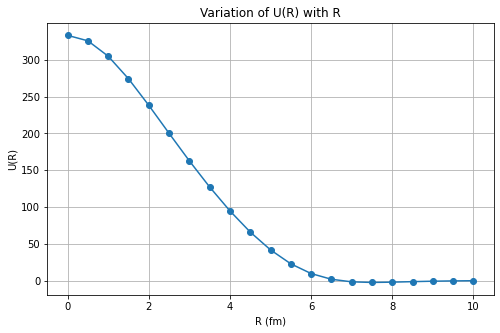

In [9]:
R_vals = np.array([0.5*i for i in range(21)])

plt.figure(figsize=(8, 5))

plt.plot(R_vals, datas, marker='o')

plt.xlabel('R (fm)')
plt.ylabel('U(R)')
plt.title('Variation of U(R) with R')

plt.grid(True)
plt.show()